In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def find_project_root(start: Path) -> Path:
    """Find the project root by looking for known project files."""
    for directory in (start, *start.parents):
        if (
            (directory / "requirements.txt").is_file()
            and (directory / "src").is_dir()
        ):
            return directory

    raise FileNotFoundError(
        f"Could not find the project root above: {start}"
    )


PROJECT_ROOT = find_project_root(Path.cwd())

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "daphnet_integrated.parquet"
)

if not DATA_PATH.is_file():
    raise FileNotFoundError(
        f"Integrated dataset was not found at: {DATA_PATH}"
    )

df = pd.read_parquet(DATA_PATH)
sns.set_theme(style="whitegrid")

print(f"Working directory: {Path.cwd()}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATA_PATH}")
print(f"Shape: {df.shape}")

df.head()

Working directory: c:\Users\chira\Parkinsons_Fog_Detection\notebooks\notebooks
Project root: c:\Users\chira\Parkinsons_Fog_Detection
Dataset path: c:\Users\chira\Parkinsons_Fog_Detection\data\processed\daphnet_integrated.parquet
Shape: (1917887, 14)


,time_ms,ankle_forward_mg,ankle_vertical_mg,ankle_lateral_mg,thigh_forward_mg,thigh_vertical_mg,thigh_lateral_mg,trunk_forward_mg,trunk_vertical_mg,trunk_lateral_mg,annotation,participant_id,recording_id,source_file
0,15,70,39,-970,0,0,0,0,0,0,0,S01,R01,C:\Users\chira\Parkinsons_Fog_Detection\data\r...
1,31,70,39,-970,0,0,0,0,0,0,0,S01,R01,C:\Users\chira\Parkinsons_Fog_Detection\data\r...
2,46,60,49,-960,0,0,0,0,0,0,0,S01,R01,C:\Users\chira\Parkinsons_Fog_Detection\data\r...
3,62,60,49,-960,0,0,0,0,0,0,0,S01,R01,C:\Users\chira\Parkinsons_Fog_Detection\data\r...
4,78,50,39,-960,0,0,0,0,0,0,0,S01,R01,C:\Users\chira\Parkinsons_Fog_Detection\data\r...


#### Validating Recordings, Durations & TS Consistencies

In [3]:
recording_summary = (
    df.groupby(
        ["participant_id", "recording_id", "source_file"],
        as_index=False,
    )
    .agg(
        sample_count=("time_ms", "size"),
        start_time_ms=("time_ms", "min"),
        end_time_ms=("time_ms", "max"),
    )
)

recording_summary["duration_minutes"] = (
    recording_summary["end_time_ms"]
    - recording_summary["start_time_ms"]
) / 60_000

recording_summary = recording_summary.sort_values(
    ["participant_id", "recording_id"]
).reset_index(drop=True)

print(f"Recordings: {len(recording_summary)}")
print(
    f"Total duration: "
    f"{recording_summary['duration_minutes'].sum():.2f} minutes"
)
print(
    f"Average recording duration: "
    f"{recording_summary['duration_minutes'].mean():.2f} minutes"
)

recording_summary[
    [
        "participant_id",
        "recording_id",
        "sample_count",
        "duration_minutes",
    ]
]

Recordings: 17
Total duration: 499.45 minutes
Average recording duration: 29.38 minutes


,participant_id,recording_id,sample_count,duration_minutes
0,S01,R01,151987,39.579683
1,S01,R02,52095,13.566150
2,S02,R01,72561,18.895833
3,S02,R02,89645,23.344800
4,S03,R01,144190,37.549217
5,S03,R02,38774,10.097133
6,S03,R03,70269,18.298967
7,S04,R01,195737,50.972917
8,S05,R01,109886,28.615883
9,S05,R02,100746,26.235683


In [4]:
time_differences = (
    df.groupby("source_file", sort=False)["time_ms"]
    .diff()
    .dropna()
)

print("Timestamp interval summary:")
print(time_differences.describe())

print(
    "\nNon-positive timestamp intervals:",
    (time_differences <= 0).sum(),
)

print(
    "Observed timestamp intervals:",
    sorted(time_differences.unique().tolist()),
)

Timestamp interval summary:
count    1.917870e+06
mean     1.562500e+01
std      4.841227e-01
min      1.500000e+01
25%      1.500000e+01
50%      1.600000e+01
75%      1.600000e+01
max      1.600000e+01
Name: time_ms, dtype: float64

Non-positive timestamp intervals: 0
Observed timestamp intervals: [15.0, 16.0]


In [5]:
EXPECTED_FREQUENCY_HZ = 64
EXPECTED_INTERVAL_MS = 1000 / EXPECTED_FREQUENCY_HZ

print(f"Expected interval: {EXPECTED_INTERVAL_MS} ms")

Expected interval: 15.625 ms


### Freezing Moments : Label Distribution

In [6]:
LABEL_NAMES = {
    0: "Outside experiment",
    1: "No freezing",
    2: "Freezing",
}

label_summary = (
    df["annotation"]
    .value_counts()
    .sort_index()
    .rename_axis("annotation")
    .reset_index(name="sample_count")
)

label_summary["label_name"] = label_summary["annotation"].map(LABEL_NAMES)
label_summary["percentage"] = (
    label_summary["sample_count"] / len(df) * 100
)

label_summary[
    ["annotation", "label_name", "sample_count", "percentage"]
]

,annotation,label_name,sample_count,percentage
0,0,Outside experiment,777052,40.516047
1,1,No freezing,1030050,53.707544
2,2,Freezing,110785,5.776409


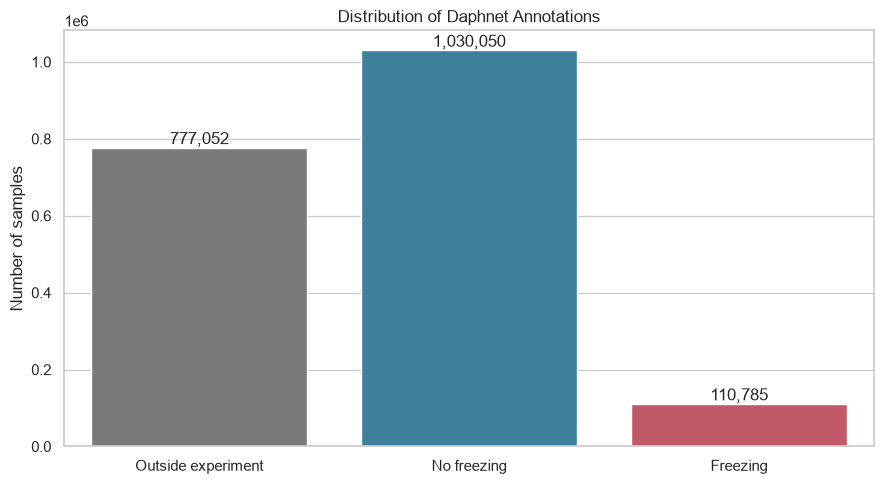

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=label_summary,
    x="label_name",
    y="sample_count",
    hue="label_name",
    palette=["#7A7A7A", "#2E86AB", "#D1495B"],
    legend=False,
    ax=ax,
)

for bar, count in zip(ax.patches, label_summary["sample_count"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom",
    )

ax.set_title("Distribution of Daphnet Annotations")
ax.set_xlabel("")
ax.set_ylabel("Number of samples")

plt.tight_layout()
plt.show()

Freezing moments are the rarest.

In [8]:
experimental_label_summary = label_summary[
    label_summary["annotation"].isin([1, 2])
].copy()

experimental_total = experimental_label_summary["sample_count"].sum()

experimental_label_summary["experimental_percentage"] = (
    experimental_label_summary["sample_count"]
    / experimental_total
    * 100
)

experimental_label_summary[
    [
        "annotation",
        "label_name",
        "sample_count",
        "experimental_percentage",
    ]
]

,annotation,label_name,sample_count,experimental_percentage
1,1,No freezing,1030050,90.28913
2,2,Freezing,110785,9.71087


## Labels by Participant

In [9]:
participant_label_counts = pd.crosstab(
    df["participant_id"],
    df["annotation"],
)

participant_label_counts = participant_label_counts.reindex(
    columns=[0, 1, 2],
    fill_value=0,
)

participant_label_counts.columns = [
    "outside_experiment",
    "no_freezing",
    "freezing",
]

participant_label_counts["experimental_samples"] = (
    participant_label_counts["no_freezing"]
    + participant_label_counts["freezing"]
)

participant_label_counts["freezing_percentage"] = (
    participant_label_counts["freezing"]
    / participant_label_counts["experimental_samples"]
    * 100
)

participant_label_counts

,outside_experiment,no_freezing,freezing,experimental_samples,freezing_percentage
participant_id,,,,,
S01,82479,114909,6694,121603,5.504798
S02,71644,78953,11609,90562,12.818842
S03,124589,110304,18340,128644,14.256398
S04,63255,132482,0,132482,0.000000
S05,76866,103396,30370,133766,22.703826
S06,92569,118952,8413,127365,6.605425
S07,66818,97829,5213,103042,5.059102
S08,87305,36425,12859,49284,26.091632
S09,60946,94078,17287,111365,15.522830


In [10]:
participants_without_freezing = participant_label_counts.index[
    participant_label_counts["freezing"] == 0
].tolist()

print("Participants without freezing:", participants_without_freezing)

Participants without freezing: ['S04', 'S10']


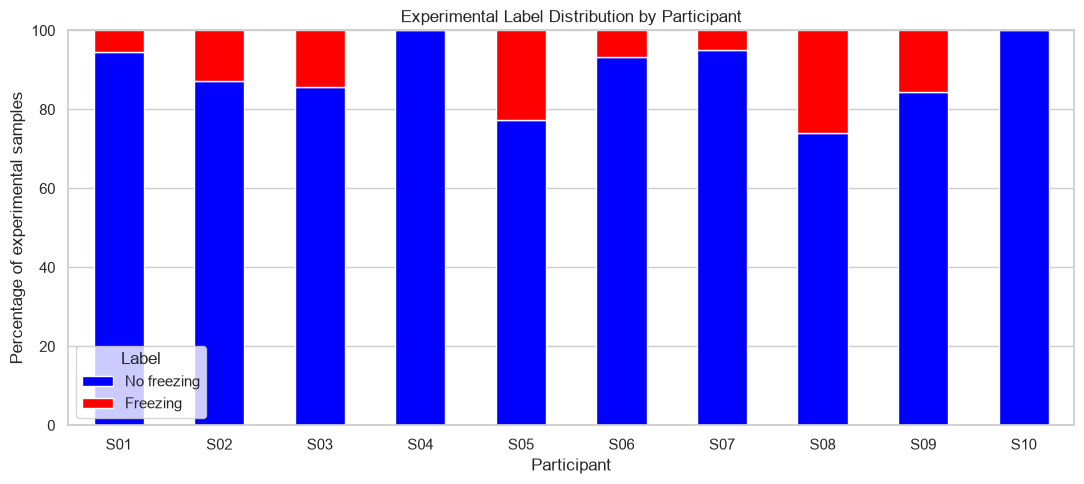

In [12]:
participant_percentages = (
    participant_label_counts[["no_freezing", "freezing"]]
    .div(
        participant_label_counts["experimental_samples"],
        axis=0,
    )
    * 100
)

ax = participant_percentages.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 5),
    color=["blue","red"],
)

ax.set_title("Experimental Label Distribution by Participant")
ax.set_xlabel("Participant")
ax.set_ylabel("Percentage of experimental samples")
ax.legend(
    title="Label",
    labels=["No freezing", "Freezing"],
)
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## Recording-level label distribution

### Aim

Examine how recording duration and freezing activity differ across the 17
recordings. This helps identify recordings with no freezing events and shows
whether the class imbalance is consistent across the dataset.

In [13]:
SAMPLING_FREQUENCY_HZ = 64


def count_label(labels: pd.Series, target_label: int) -> int:
    """Count how many samples have a particular annotation."""
    return int((labels == target_label).sum())


# Each row in this table will represent one complete recording.
recording_summary = (
    df.groupby(
        ["participant_id", "recording_id", "source_file"],
        as_index=False,
    )
    .agg(
        total_samples=("annotation", "size"),
        outside_experiment_samples=(
            "annotation",
            lambda labels: count_label(labels, 0),
        ),
        no_freezing_samples=(
            "annotation",
            lambda labels: count_label(labels, 1),
        ),
        freezing_samples=(
            "annotation",
            lambda labels: count_label(labels, 2),
        ),
    )
)

# recording_id values such as R01 are repeated between participants.
# Combining both IDs gives every recording a unique, readable name.
recording_summary["recording_name"] = (
    recording_summary["participant_id"]
    + recording_summary["recording_id"]
)

# Estimate duration from the documented sampling frequency of 64 Hz.
recording_summary["duration_minutes"] = (
    recording_summary["total_samples"]
    / SAMPLING_FREQUENCY_HZ
    / 60
)

recording_summary["experimental_samples"] = (
    recording_summary["no_freezing_samples"]
    + recording_summary["freezing_samples"]
)

# Label 0 is excluded because it represents time outside the experiment.
recording_summary["freezing_percentage"] = (
    recording_summary["freezing_samples"]
    / recording_summary["experimental_samples"]
    * 100
)

recording_summary = recording_summary.sort_values(
    ["participant_id", "recording_id"]
).reset_index(drop=True)

columns_to_display = [
    "recording_name",
    "duration_minutes",
    "outside_experiment_samples",
    "no_freezing_samples",
    "freezing_samples",
    "freezing_percentage",
]

recording_summary[columns_to_display].round(2)

,recording_name,duration_minutes,outside_experiment_samples,no_freezing_samples,freezing_samples,freezing_percentage
0,S01R01,39.58,59185,87655,5147,5.55
1,S01R02,13.57,23294,27254,1547,5.37
2,S02R01,18.90,46960,22064,3537,13.82
3,S02R02,23.35,24684,56889,8072,12.43
4,S03R01,37.55,53308,74848,16034,17.64
5,S03R02,10.10,22133,14335,2306,13.86
6,S03R03,18.30,49148,21121,0,0.00
7,S04R01,50.97,63255,132482,0,0.00
8,S05R01,28.62,42042,50491,17353,25.58
9,S05R02,26.24,34824,52905,13017,19.75


In [14]:
assert len(recording_summary) == 17

total_duration_hours = (
    recording_summary["duration_minutes"].sum() / 60
)

print(f"Number of recordings: {len(recording_summary)}")
print(f"Approximate total duration: {total_duration_hours:.2f} hours")

Number of recordings: 17
Approximate total duration: 8.32 hours


In [15]:
recordings_without_freezing = recording_summary.loc[
    recording_summary["freezing_samples"] == 0,
    "recording_name",
].tolist()

print("Recordings without freezing:")
for recording_name in recordings_without_freezing:
    print(f"  - {recording_name}")

Recordings without freezing:
  - S03R03
  - S04R01
  - S06R02
  - S10R01


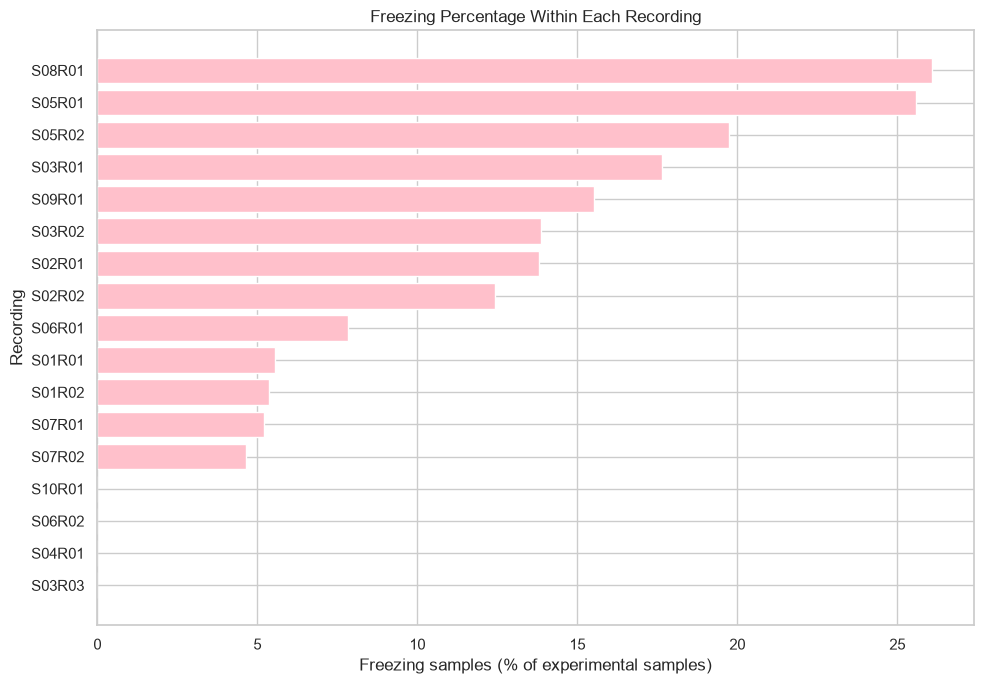

In [19]:
plot_data = recording_summary.sort_values(
    "freezing_percentage",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(10, 7))

bar_colors = [
    "pink" if percentage > 0 else "gray"
    for percentage in plot_data["freezing_percentage"]
]

ax.barh(
    plot_data["recording_name"],
    plot_data["freezing_percentage"],
    color=bar_colors,
)

ax.set_title("Freezing Percentage Within Each Recording")
ax.set_xlabel("Freezing samples (% of experimental samples)")
ax.set_ylabel("Recording")

plt.tight_layout()
plt.show()

## Freezing episode duration

### Aim

Identify contiguous freezing episodes and study their durations. Sample-level
class counts do not show whether freezing consists of many short events or a
small number of prolonged events.

An episode begins when the annotation changes from a non-freezing label to
label 2. Episodes are calculated separately within each recording.

In [20]:
# Use only the columns needed for episode analysis.
episode_data = df[
    [
        "time_ms",
        "annotation",
        "participant_id",
        "recording_id",
        "source_file",
    ]
].copy()

episode_data = episode_data.sort_values(
    ["source_file", "time_ms"]
).reset_index(drop=True)

is_freezing = episode_data["annotation"].eq(2)

# Look at the preceding label within the same recording.
previous_label = episode_data.groupby(
    "source_file",
    sort=False,
)["annotation"].shift()

# A new episode starts whenever label 2 follows a different label.
episode_start = is_freezing & previous_label.ne(2)

episode_data["fog_episode_id"] = episode_start.groupby(
    episode_data["source_file"]
).cumsum()

# Summarize each contiguous block of label-2 samples.
fog_episodes = (
    episode_data.loc[is_freezing]
    .groupby(
        [
            "participant_id",
            "recording_id",
            "source_file",
            "fog_episode_id",
        ],
        as_index=False,
    )
    .agg(
        start_time_ms=("time_ms", "min"),
        end_time_ms=("time_ms", "max"),
        sample_count=("time_ms", "size"),
    )
)

fog_episodes["duration_seconds"] = (
    fog_episodes["sample_count"] / SAMPLING_FREQUENCY_HZ
)

print(f"Number of freezing episodes: {len(fog_episodes)}")
fog_episodes["duration_seconds"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
)

Number of freezing episodes: 237


count    237.000000
mean       7.303863
std        6.698721
min        0.437500
25%        2.468750
50%        5.343750
75%        9.828125
90%       15.684375
95%       20.481250
max       40.531250
Name: duration_seconds, dtype: float64

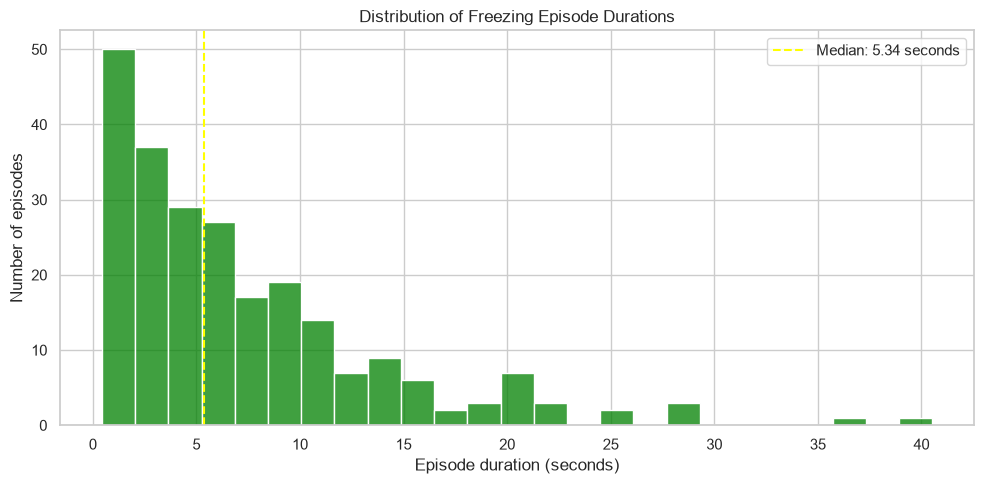

In [21]:
median_duration = fog_episodes["duration_seconds"].median()

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=fog_episodes,
    x="duration_seconds",
    bins=25,
    color="green",
    edgecolor="white",
    ax=ax,
)

ax.axvline(
    median_duration,
    color="yellow",
    linestyle="--",
    label=f"Median: {median_duration:.2f} seconds",
)

ax.set_title("Distribution of Freezing Episode Durations")
ax.set_xlabel("Episode duration (seconds)")
ax.set_ylabel("Number of episodes")
ax.legend()

plt.tight_layout()
plt.show()

In [22]:
participant_episode_summary = (
    fog_episodes.groupby("participant_id")
    .agg(
        episode_count=("fog_episode_id", "size"),
        total_freezing_seconds=("duration_seconds", "sum"),
        median_episode_seconds=("duration_seconds", "median"),
        longest_episode_seconds=("duration_seconds", "max"),
    )
    .round(2)
)

participant_episode_summary

,episode_count,total_freezing_seconds,median_episode_seconds,longest_episode_seconds
participant_id,,,,
S01,23,104.59,2.25,15.20
S02,24,181.39,6.88,18.41
S03,49,286.56,4.91,20.72
S05,66,474.53,5.75,28.59
S06,10,131.45,4.73,40.53
S07,24,81.45,2.77,11.50
S08,14,200.92,14.69,21.42
S09,27,270.11,6.91,37.03


## Sensor behaviour around freezing episodes

### Aim

Visualize ankle, thigh, and trunk acceleration immediately before, during,
and after freezing. This helps determine whether freezing has visible temporal
patterns and which sensor locations appear most informative.

The signals remain in their original milligravity (mg) units. No filtering,
normalization, or feature engineering is applied.

In [24]:
SENSOR_GROUPS = {
    "Ankle": [
        "ankle_forward_mg",
        "ankle_vertical_mg",
        "ankle_lateral_mg",
    ],
    "Thigh": [
        "thigh_forward_mg",
        "thigh_vertical_mg",
        "thigh_lateral_mg",
    ],
    "Trunk": [
        "trunk_forward_mg",
        "trunk_vertical_mg",
        "trunk_lateral_mg",
    ],
}

AXIS_COLORS = ["#2E86AB", "#D1495B", "#3A7D44"]


def plot_episode_context(
    episode: pd.Series,
    padding_seconds: float = 5,
) -> None:
    """Plot sensor signals before, during, and after one freezing episode."""

    padding_ms = padding_seconds * 1_000
    start_ms = episode["start_time_ms"]
    end_ms = episode["end_time_ms"]

    # Select data from the same recording around this episode.
    window = df[
        (df["source_file"] == episode["source_file"])
        & (df["time_ms"] >= start_ms - padding_ms)
        & (df["time_ms"] <= end_ms + padding_ms)
    ].copy()

    # Time zero marks the beginning of freezing.
    window["relative_time_seconds"] = (
        window["time_ms"] - start_ms
    ) / 1_000

    figure, axes = plt.subplots(
        nrows=4,
        ncols=1,
        figsize=(13, 10),
        sharex=True,
    )

    for axis, (sensor_name, columns) in zip(
        axes[:3],
        SENSOR_GROUPS.items(),
    ):
        for column, color in zip(columns, AXIS_COLORS):
            readable_axis_name = column.split("_")[1].title()

            axis.plot(
                window["relative_time_seconds"],
                window[column],
                label=readable_axis_name,
                color=color,
                linewidth=0.9,
            )

        axis.axvspan(
            0,
            episode["duration_seconds"],
            color="#D1495B",
            alpha=0.15,
        )

        axis.set_ylabel("Acceleration (mg)")
        axis.set_title(f"{sensor_name} accelerometer")
        axis.legend(loc="upper right", ncols=3)

    # Show the annotations separately to avoid hiding sensor signals.
    axes[3].step(
        window["relative_time_seconds"],
        window["annotation"],
        where="post",
        color="black",
    )

    axes[3].set_yticks([0, 1, 2])
    axes[3].set_yticklabels(
        ["Outside", "No FoG", "FoG"]
    )
    axes[3].set_xlabel("Time relative to freezing onset (seconds)")
    axes[3].set_ylabel("Label")

    recording_name = (
        episode["participant_id"] + episode["recording_id"]
    )

    figure.suptitle(
        f"{recording_name}: {episode['duration_seconds']:.2f}-second "
        "freezing episode",
        fontsize=14,
    )

    plt.tight_layout()
    plt.show()

Typical episode:
participant_id          S03
recording_id            R01
duration_seconds    5.34375
Name: 69, dtype: object


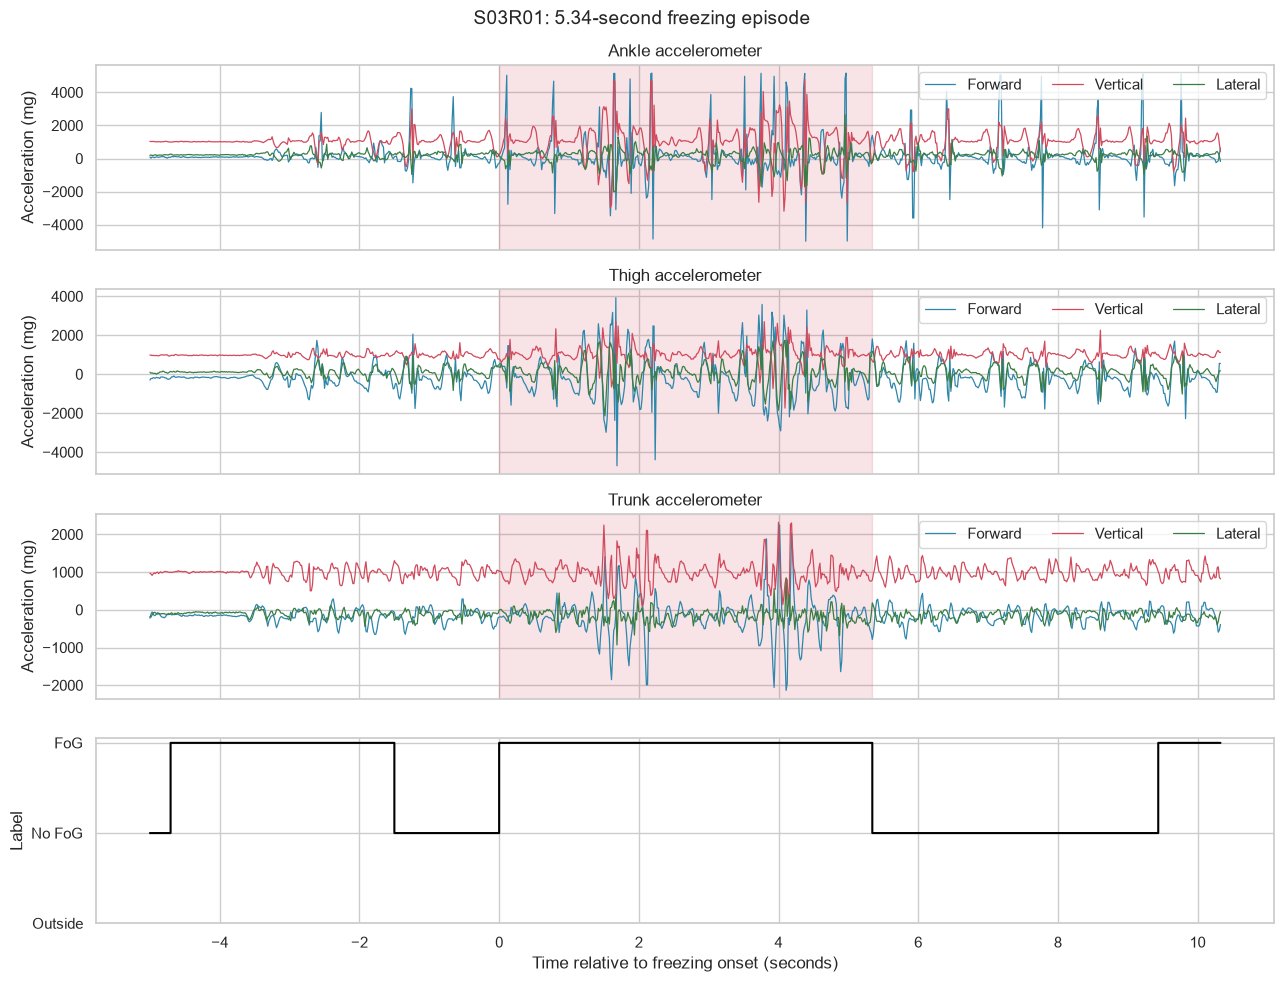

In [25]:
median_duration = fog_episodes["duration_seconds"].median()

typical_episode_index = (
    fog_episodes["duration_seconds"] - median_duration
).abs().idxmin()

typical_episode = fog_episodes.loc[typical_episode_index]

print("Typical episode:")
print(typical_episode[
    [
        "participant_id",
        "recording_id",
        "duration_seconds",
    ]
])

plot_episode_context(typical_episode)

Longest episode:
participant_id           S06
recording_id             R01
duration_seconds    40.53125
Name: 166, dtype: object


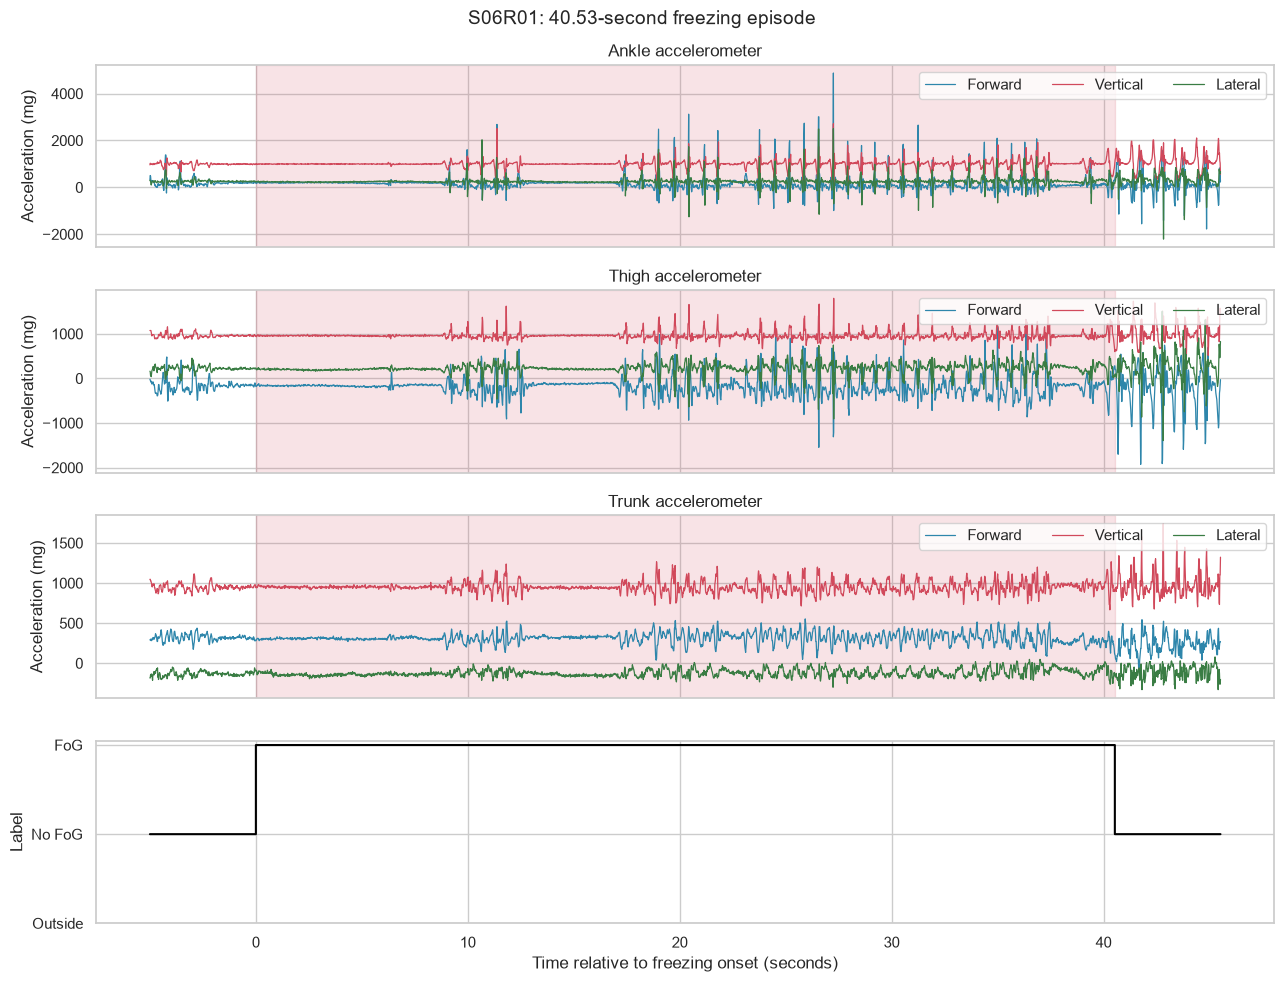

In [26]:
longest_episode_index = (
    fog_episodes["duration_seconds"].idxmax()
)

longest_episode = fog_episodes.loc[longest_episode_index]

print("Longest episode:")
print(longest_episode[
    [
        "participant_id",
        "recording_id",
        "duration_seconds",
    ]
])

plot_episode_context(longest_episode)

## Sensor variability during freezing

### Aim

Compare the spread of each accelerometer axis during freezing and non-freezing
experimental periods.

The interquartile range (IQR) is used because acceleration signals may contain
large spikes. An IQR ratio above 1 means that an axis is more variable during
freezing; a ratio below 1 means it is less variable during freezing.

In [27]:
SENSOR_COLUMNS = [
    column
    for columns in SENSOR_GROUPS.values()
    for column in columns
]

# Label 0 is excluded because it is outside the experiment.
experimental_data = df.loc[
    df["annotation"].isin([1, 2]),
    ["participant_id", "annotation", *SENSOR_COLUMNS],
]

grouped_signals = experimental_data.groupby(
    ["participant_id", "annotation"]
)[SENSOR_COLUMNS]

# IQR measures the width of the middle 50% of observations.
signal_iqr = (
    grouped_signals.quantile(0.75)
    - grouped_signals.quantile(0.25)
)

no_freezing_iqr = signal_iqr.xs(
    1,
    level="annotation",
)

freezing_iqr = signal_iqr.xs(
    2,
    level="annotation",
)

iqr_ratio = freezing_iqr / no_freezing_iqr

iqr_ratio.round(2)

,ankle_forward_mg,ankle_vertical_mg,ankle_lateral_mg,thigh_forward_mg,thigh_vertical_mg,thigh_lateral_mg,trunk_forward_mg,trunk_vertical_mg,trunk_lateral_mg
participant_id,,,,,,,,,
S01,1.00,1.43,0.95,0.55,0.45,1.24,1.16,1.66,0.77
S02,0.69,1.04,1.14,0.89,0.33,0.81,1.16,1.91,0.64
S03,1.77,1.72,0.91,0.51,0.18,1.93,1.20,2.28,0.27
S04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
S05,0.76,0.77,0.28,0.62,0.29,0.45,0.60,0.69,0.21
S06,1.17,1.00,0.69,0.23,0.11,0.26,0.32,0.69,0.60
S07,1.00,1.18,0.91,0.64,0.76,0.87,1.00,1.48,1.12
S08,0.80,1.20,0.86,0.95,1.02,0.90,0.85,1.00,0.90
S09,0.54,0.98,1.00,0.48,0.14,0.30,0.38,1.79,0.44


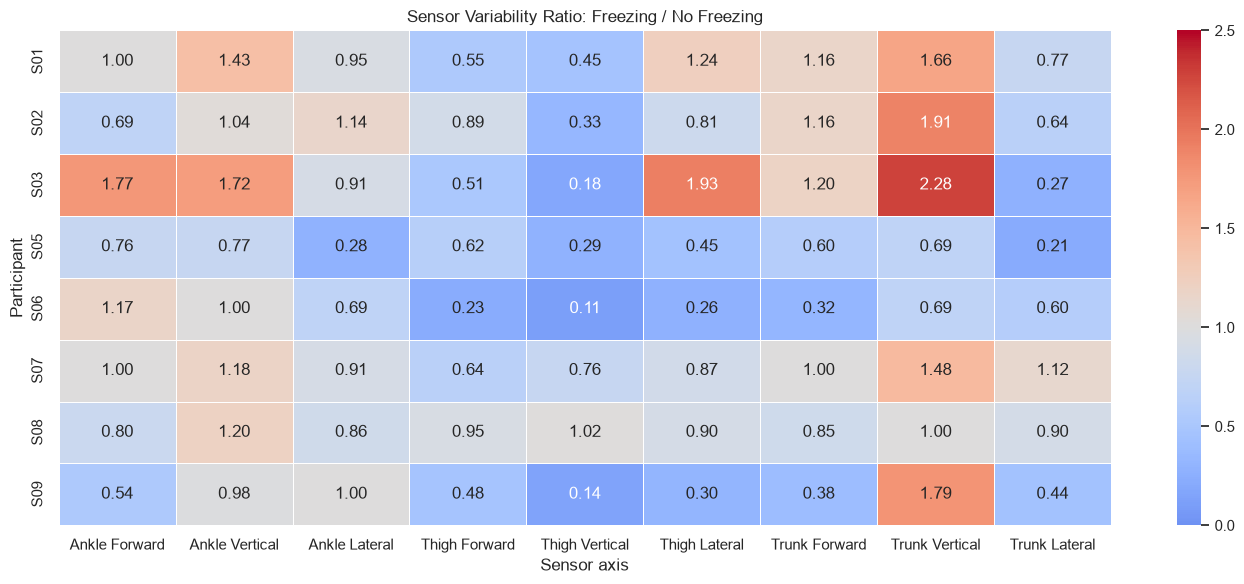

In [28]:
readable_sensor_names = {
    column: column.removesuffix("_mg").replace("_", " ").title()
    for column in SENSOR_COLUMNS
}

heatmap_data = (
    iqr_ratio
    .dropna(how="all")
    .rename(columns=readable_sensor_names)
)

fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=1,
    vmin=0,
    vmax=2.5,
    linewidths=0.5,
    ax=ax,
)

ax.set_title("Sensor Variability Ratio: Freezing / No Freezing")
ax.set_xlabel("Sensor axis")
ax.set_ylabel("Participant")

plt.tight_layout()
plt.show()

In [29]:
median_iqr_ratio = (
    iqr_ratio
    .median()
    .rename(index=readable_sensor_names)
    .sort_values(ascending=False)
    .rename("median_iqr_ratio")
)

median_iqr_ratio.round(2)

Trunk Vertical    1.57
Ankle Vertical    1.11
Trunk Forward     0.92
Ankle Lateral     0.91
Ankle Forward     0.90
Thigh Lateral     0.84
Trunk Lateral     0.62
Thigh Forward     0.58
Thigh Vertical    0.31
Name: median_iqr_ratio, dtype: float64

## Hidden sensor dropout

### Aim

Detect periods where all three axes from a sensor are exactly zero. These
periods are not represented as missing values, but long zero runs may indicate
an inactive or unavailable sensor.

No rows are removed during this analysis.

In [30]:
quality_columns = [
    "participant_id",
    "recording_id",
    "annotation",
    *SENSOR_COLUMNS,
]

# Restrict the diagnostic to the actual experiment.
experimental_quality = df.loc[
    df["annotation"].isin([1, 2]),
    quality_columns,
].copy()

zero_flag_columns = []

for sensor_name, sensor_axes in SENSOR_GROUPS.items():
    flag_name = f"{sensor_name.lower()}_all_zero"

    experimental_quality[flag_name] = (
        experimental_quality[sensor_axes]
        .eq(0)
        .all(axis=1)
    )

    zero_flag_columns.append(flag_name)

In [31]:
zero_sensor_summary = pd.DataFrame({
    "zero_triplet_samples": (
        experimental_quality[zero_flag_columns].sum()
    ),
    "percentage_of_experiment": (
        experimental_quality[zero_flag_columns].mean() * 100
    ),
})

zero_sensor_summary.index = [
    name.replace("_all_zero", "").title()
    for name in zero_sensor_summary.index
]

zero_sensor_summary.round(2)

,zero_triplet_samples,percentage_of_experiment
Ankle,0,0.00
Thigh,45149,3.96
Trunk,24299,2.13


In [32]:
recording_zero_percentages = (
    experimental_quality
    .groupby(["participant_id", "recording_id"])[zero_flag_columns]
    .mean()
    .mul(100)
    .reset_index()
)

recording_zero_percentages["recording_name"] = (
    recording_zero_percentages["participant_id"]
    + recording_zero_percentages["recording_id"]
)

recording_zero_percentages

,participant_id,recording_id,ankle_all_zero,thigh_all_zero,trunk_all_zero,recording_name
0,S01,R01,0.0,0.000000,0.000000,S01R01
1,S01,R02,0.0,0.000000,0.000000,S01R02
2,S02,R01,0.0,0.000000,0.000000,S02R01
3,S02,R02,0.0,0.000000,0.000000,S02R02
4,S03,R01,0.0,0.000000,0.000000,S03R01
5,S03,R02,0.0,0.000000,0.000000,S03R02
6,S03,R03,0.0,100.000000,0.000000,S03R03
7,S04,R01,0.0,0.000000,0.000000,S04R01
8,S05,R01,0.0,0.000000,0.000000,S05R01
9,S05,R02,0.0,0.000000,0.000000,S05R02


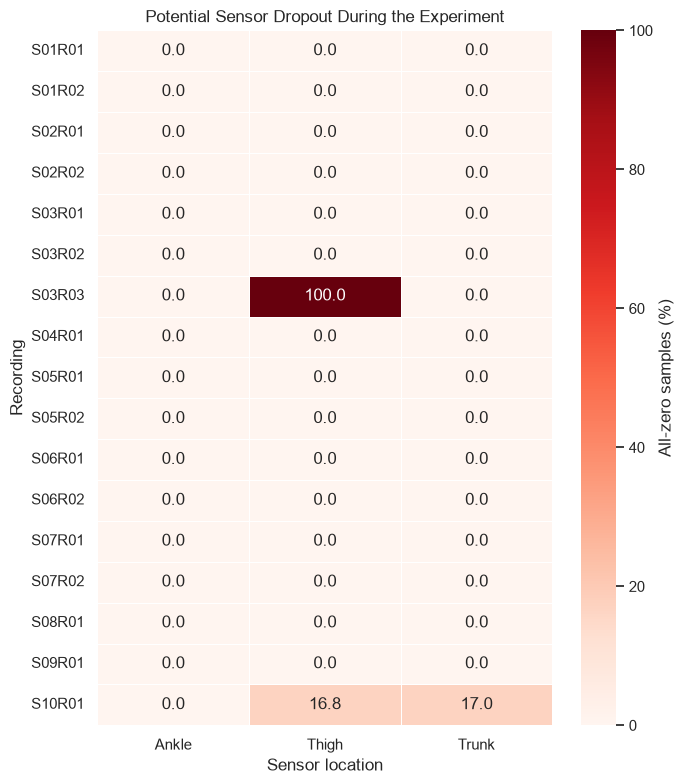

In [33]:
dropout_heatmap = (
    recording_zero_percentages
    .set_index("recording_name")[zero_flag_columns]
    .rename(
        columns={
            "ankle_all_zero": "Ankle",
            "thigh_all_zero": "Thigh",
            "trunk_all_zero": "Trunk",
        }
    )
)

fig, ax = plt.subplots(figsize=(7, 8))

sns.heatmap(
    dropout_heatmap,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    cbar_kws={"label": "All-zero samples (%)"},
    ax=ax,
)

ax.set_title("Potential Sensor Dropout During the Experiment")
ax.set_xlabel("Sensor location")
ax.set_ylabel("Recording")

plt.tight_layout()
plt.show()

## Sensor ranges and extreme values

### Aim

Examine the typical and extreme values recorded by each accelerometer axis.
This can reveal unusually large readings, possible clipping, and axes whose
scales differ substantially.

Only experimental labels 1 and 2 are included. No observations are removed.

In [34]:
import numpy as np


experimental_signals = df.loc[
    df["annotation"].isin([1, 2]),
    SENSOR_COLUMNS,
]

selected_quantiles = experimental_signals.quantile(
    [0.001, 0.01, 0.50, 0.99, 0.999]
).T

sensor_range_summary = selected_quantiles.rename(
    columns={
        0.001: "0.1%",
        0.01: "1%",
        0.50: "median",
        0.99: "99%",
        0.999: "99.9%",
    }
)

sensor_range_summary.insert(
    0,
    "minimum",
    experimental_signals.min(),
)

sensor_range_summary["maximum"] = experimental_signals.max()

sensor_range_summary = sensor_range_summary.rename(
    index=readable_sensor_names
)

sensor_range_summary.round(2)

,minimum,0.1%,1%,median,99%,99.9%,maximum
Ankle Forward,-31234,-4070.0,-1959.0,-70.0,1313.0,3525.0,27651
Ankle Vertical,-32255,-490.0,196.0,990.0,2098.0,3098.0,31493
Ankle Lateral,-31487,-1891.0,-594.0,237.0,861.0,1712.0,29437
Thigh Forward,-21846,-1936.0,-1045.0,-27.0,1072.0,2090.0,22596
Thigh Vertical,-29673,-18.0,0.0,925.0,1537.0,2083.0,22596
Thigh Lateral,-23908,-1000.0,-575.0,141.0,767.0,1070.0,22596
Trunk Forward,-3951,-854.0,-456.0,38.0,572.0,854.0,6707
Trunk Vertical,-1323,0.0,0.0,980.0,1428.0,1885.0,24298
Trunk Lateral,-4242,-2145.0,-378.0,-9.0,572.0,621.0,4300


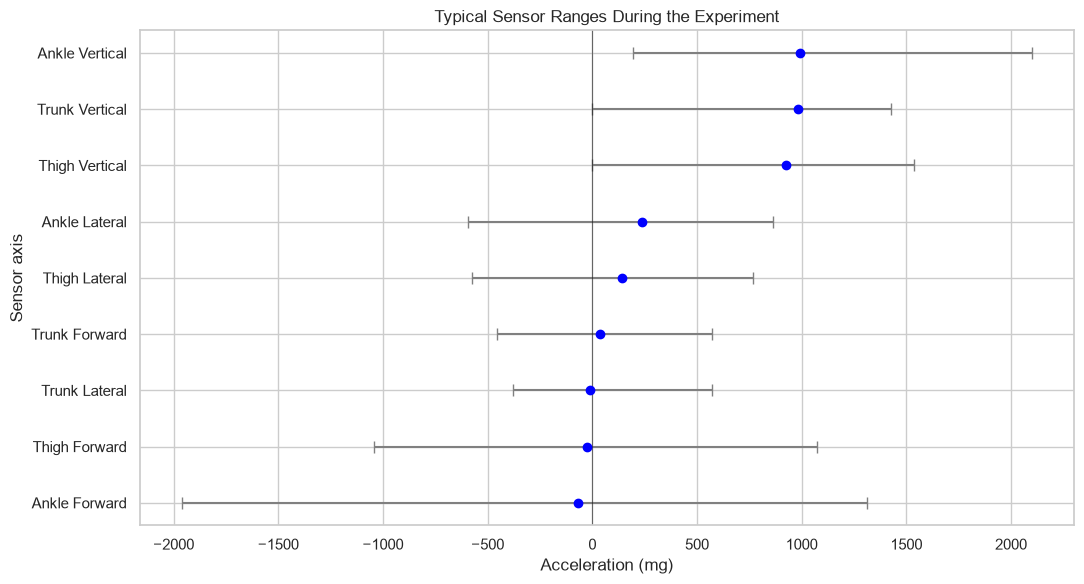

In [36]:
plot_ranges = sensor_range_summary.sort_values("median")

lower_distance = (
    plot_ranges["median"] - plot_ranges["1%"]
)

upper_distance = (
    plot_ranges["99%"] - plot_ranges["median"]
)

fig, ax = plt.subplots(figsize=(11, 6))

ax.errorbar(
    x=plot_ranges["median"],
    y=plot_ranges.index,
    xerr=np.vstack([lower_distance, upper_distance]),
    fmt="o",
    color ="blue",
    ecolor="grey",
    capsize=4,
)

ax.axvline(0, color="black", linewidth=0.8, alpha=0.5)
ax.set_title("Typical Sensor Ranges During the Experiment")
ax.set_xlabel("Acceleration (mg)")
ax.set_ylabel("Sensor axis")

plt.tight_layout()
plt.show()

Checking whether minimum or maximum values repeat suspiciously often 

In [37]:
extreme_value_rows = []

for column in SENSOR_COLUMNS:
    values = experimental_signals[column]
    minimum = values.min()
    maximum = values.max()

    extreme_value_rows.append({
        "sensor_axis": readable_sensor_names[column],
        "minimum": minimum,
        "minimum_count": int((values == minimum).sum()),
        "maximum": maximum,
        "maximum_count": int((values == maximum).sum()),
    })

extreme_value_summary = pd.DataFrame(extreme_value_rows)
extreme_value_summary

,sensor_axis,minimum,minimum_count,maximum,maximum_count
0,Ankle Forward,-31234,1,27651,1
1,Ankle Vertical,-32255,3,31493,5
2,Ankle Lateral,-31487,2,29437,1
3,Thigh Forward,-21846,1,22596,27
4,Thigh Vertical,-29673,1,22596,2
5,Thigh Lateral,-23908,1,22596,1
6,Trunk Forward,-3951,1,6707,2
7,Trunk Vertical,-1323,1,24298,2
8,Trunk Lateral,-4242,1,4300,1


## Movement around freezing onset

### Aim

Combine information from many freezing episodes to examine how movement changes
immediately before and after freezing begins.

Each episode is aligned at freezing onset. Sensor values are compared with the
episode's pre-onset median so participant posture and sensor orientation have
less influence on the visualization.

This transformation is used only for EDA and is not saved to the dataset.

In [39]:
CONTEXT_SECONDS = 3
CONTEXT_SAMPLES = CONTEXT_SECONDS * SAMPLING_FREQUENCY_HZ

recording_columns = [
    "time_ms",
    "annotation",
    *SENSOR_COLUMNS,
]

# Preparing recordings once avoids repeatedly scanning the full DataFrame.
recordings_by_file = {
    source_file: recording[recording_columns]
    .sort_values("time_ms")
    .reset_index(drop=True)
    for source_file, recording in df.groupby("source_file")
}

aligned_episode_windows = []

for episode in fog_episodes.itertuples(index=False):
    recording = recordings_by_file[episode.source_file]

    onset_position = recording["time_ms"].searchsorted(
        episode.start_time_ms
    )

    window_start = onset_position - CONTEXT_SAMPLES
    window_end = onset_position + CONTEXT_SAMPLES + 1

    # Skip episodes without a complete three-second context.
    if window_start < 0 or window_end > len(recording):
        continue

    # Only analyze onsets that begin after a non-freezing sample.
    if recording.iloc[onset_position - 1]["annotation"] != 1:
        continue

    window = recording.iloc[window_start:window_end].copy()

    pre_onset_values = window.iloc[
        :CONTEXT_SAMPLES
    ][SENSOR_COLUMNS]

    pre_onset_baseline = pre_onset_values.median()

    # Absolute change prevents opposite signal directions from cancelling.
    signal_change = (
        window[SENSOR_COLUMNS] - pre_onset_baseline
    ).abs()

    signal_change["relative_sample"] = np.arange(
        -CONTEXT_SAMPLES,
        CONTEXT_SAMPLES + 1,
    )

    signal_change["is_freezing"] = (
        window["annotation"].to_numpy() == 2
    )

    aligned_episode_windows.append(signal_change)

onset_data = pd.concat(
    aligned_episode_windows,
    ignore_index=True,
)

print(
    "Episodes included in onset analysis:",
    len(aligned_episode_windows),
)

Episodes included in onset analysis: 237


In [40]:
onset_groups = onset_data.groupby("relative_sample")

median_onset_change = onset_groups[SENSOR_COLUMNS].median()
lower_onset_change = onset_groups[SENSOR_COLUMNS].quantile(0.25)
upper_onset_change = onset_groups[SENSOR_COLUMNS].quantile(0.75)

freezing_fraction = onset_groups["is_freezing"].mean()

relative_seconds = (
    median_onset_change.index / SAMPLING_FREQUENCY_HZ
)

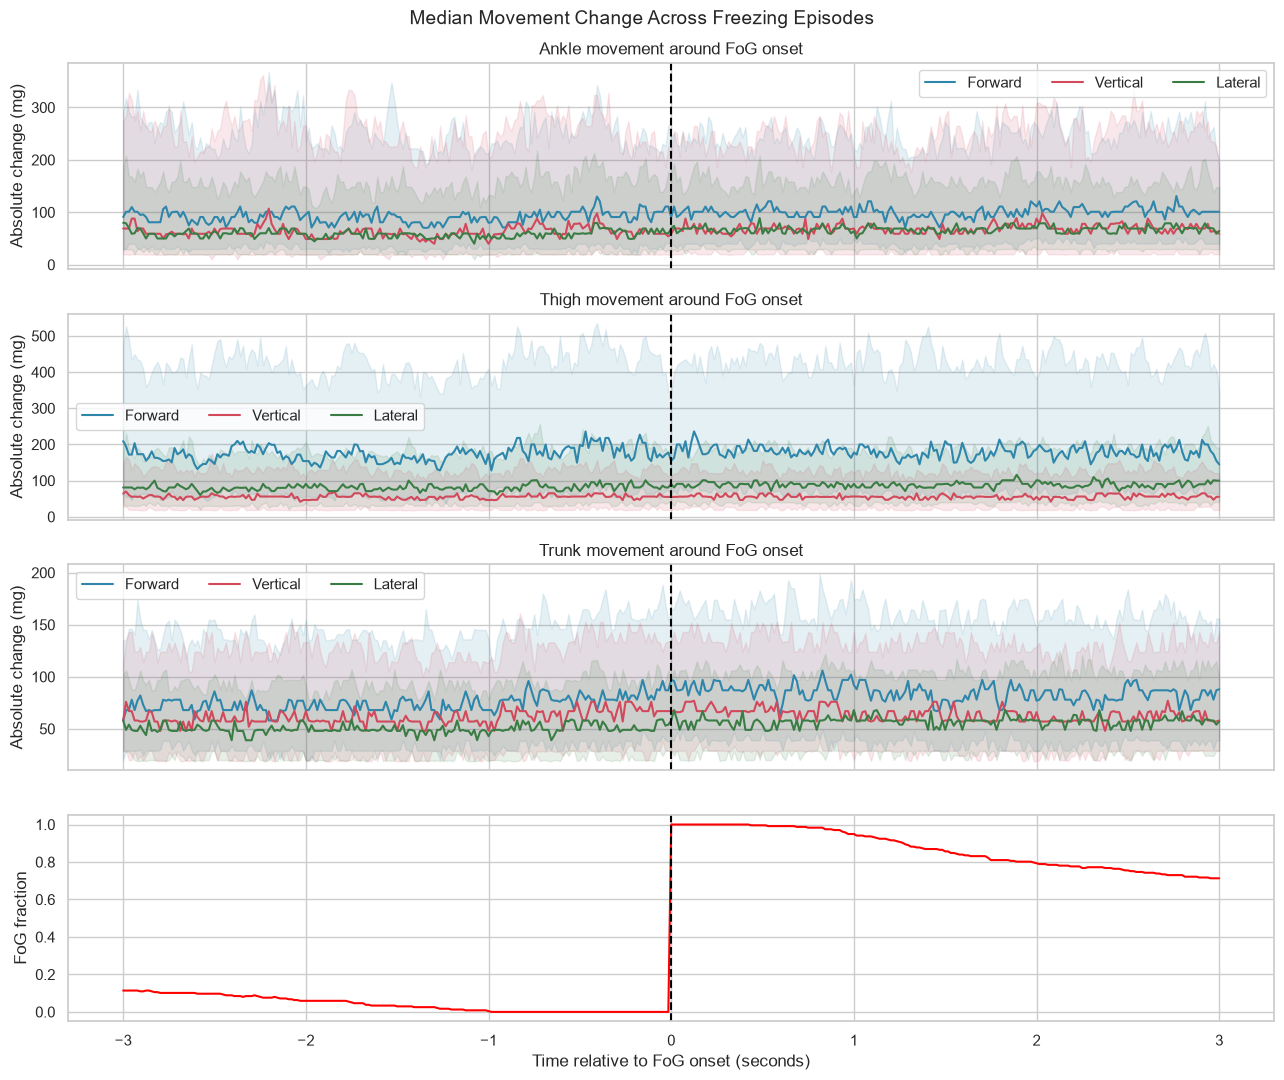

In [42]:
fig, axes = plt.subplots(
    4,
    1,
    figsize=(13, 11),
    sharex=True,
)

for ax, (sensor_name, sensor_axes) in zip(
    axes[:3],
    SENSOR_GROUPS.items(),
):
    for column, color in zip(sensor_axes, AXIS_COLORS):
        axis_name = column.split("_")[1].title()

        ax.plot(
            relative_seconds,
            median_onset_change[column],
            color=color,
            label=axis_name,
        )

        ax.fill_between(
            relative_seconds,
            lower_onset_change[column],
            upper_onset_change[column],
            color=color,
            alpha=0.12,
        )

    ax.axvline(0, color="black", linestyle="--")
    ax.set_title(f"{sensor_name} movement around FoG onset")
    ax.set_ylabel("Absolute change (mg)")
    ax.legend(ncols=3)

axes[3].plot(
    relative_seconds,
    freezing_fraction,
    color="red",
)

axes[3].axvline(0, color="black", linestyle="--")
axes[3].set_ylabel("FoG fraction")
axes[3].set_xlabel("Time relative to FoG onset (seconds)")
axes[3].set_ylim(-0.05, 1.05)

fig.suptitle(
    "Median Movement Change Across Freezing Episodes",
    fontsize=14,
)

plt.tight_layout()
plt.show()

## Participant-specific sensor distributions

### Aim

Measure how strongly baseline sensor values differ between participants.
Wearable placement, orientation, posture, and movement style can all produce
participant-specific signal patterns.

This analysis uses label 1 so freezing prevalence does not determine the
participant comparison.

In [43]:
no_freezing_data = df.loc[
    df["annotation"] == 1,
    ["participant_id", *SENSOR_COLUMNS],
]

participant_sensor_medians = (
    no_freezing_data
    .groupby("participant_id")[SENSOR_COLUMNS]
    .median()
)

overall_sensor_median = (
    no_freezing_data[SENSOR_COLUMNS].median()
)

overall_sensor_iqr = (
    no_freezing_data[SENSOR_COLUMNS].quantile(0.75)
    - no_freezing_data[SENSOR_COLUMNS].quantile(0.25)
)

# Express each participant's median relative to the dataset's typical spread.
standardized_participant_shift = (
    participant_sensor_medians - overall_sensor_median
).div(
    overall_sensor_iqr.replace(0, np.nan)
)

standardized_participant_shift = (
    standardized_participant_shift.rename(
        columns=readable_sensor_names
    )
)

standardized_participant_shift.round(2)

,Ankle Forward,Ankle Vertical,Ankle Lateral,Thigh Forward,Thigh Vertical,Thigh Lateral,Trunk Forward,Trunk Vertical,Trunk Lateral
participant_id,,,,,,,,,
S01,-0.26,-0.08,0.50,0.08,0.07,0.31,0.04,0.00,0.54
S02,-0.33,-0.08,0.45,0.20,0.09,0.04,-0.46,0.00,0.28
S03,0.09,-0.16,0.60,-0.65,-1.17,-0.31,-0.08,-0.09,-0.25
S04,-0.40,0.08,-0.60,0.28,0.09,0.00,-0.25,0.00,-0.25
S05,0.05,0.15,0.10,0.35,0.05,-0.15,-0.17,-0.20,0.00
S06,0.42,0.08,0.20,-0.25,0.05,0.27,0.75,-0.09,-0.50
S07,0.44,0.30,-0.30,-0.27,0.09,0.04,0.21,0.21,0.00
S08,0.49,0.00,0.45,-0.38,0.05,0.35,-0.08,0.21,-0.61
S09,0.65,0.15,-0.35,-0.73,-0.12,0.96,-0.04,0.00,0.61


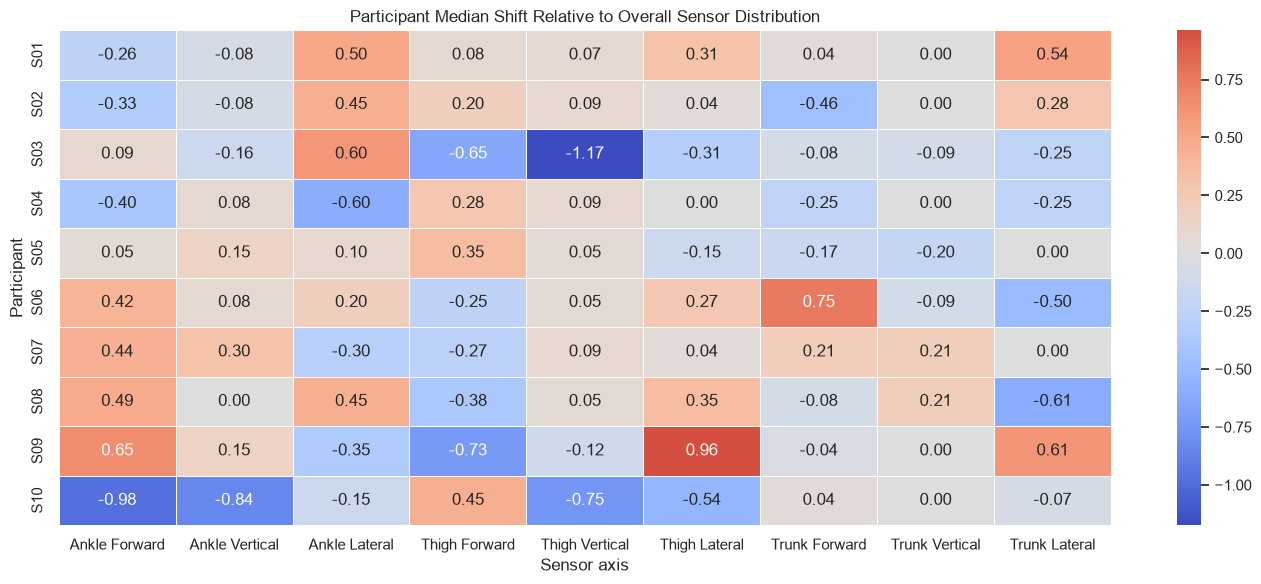

In [44]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    standardized_participant_shift,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
)

ax.set_title(
    "Participant Median Shift Relative to Overall Sensor Distribution"
)
ax.set_xlabel("Sensor axis")
ax.set_ylabel("Participant")

plt.tight_layout()
plt.show()

In [45]:
participant_shift_summary = (
    standardized_participant_shift
    .abs()
    .median(axis=1)
    .sort_values(ascending=False)
    .rename("median_absolute_shift")
)

participant_shift_summary.round(2)

participant_id
S10    0.45
S09    0.35
S08    0.35
S06    0.25
S03    0.25
S04    0.25
S07    0.21
S02    0.20
S05    0.15
S01    0.08
Name: median_absolute_shift, dtype: float64

## EDA conclusions

### Aim

Collect the main findings and translate them into evidence-based recommendations
for preprocessing and experimental design. These are recommendations only; no
cleaning, windowing, feature engineering, or modelling is performed here.

In [46]:
experimental_sample_count = int(
    df["annotation"].isin([1, 2]).sum()
)

freezing_sample_count = int(
    (df["annotation"] == 2).sum()
)

freezing_percentage = (
    freezing_sample_count
    / experimental_sample_count
    * 100
)

short_episode_percentage = (
    fog_episodes["duration_seconds"].le(2).mean() * 100
)

long_episode_percentage = (
    fog_episodes["duration_seconds"].gt(10).mean() * 100
)

eda_findings = pd.DataFrame([
    {
        "area": "Dataset size",
        "finding": (
            f"{len(df):,} samples, "
            f"{df['participant_id'].nunique()} participants and "
            f"{df['source_file'].nunique()} recordings"
        ),
    },
    {
        "area": "Class balance",
        "finding": (
            f"FoG represents {freezing_percentage:.2f}% "
            "of experimental samples"
        ),
    },
    {
        "area": "Participant coverage",
        "finding": (
            "No FoG for: "
            + ", ".join(participants_without_freezing)
        ),
    },
    {
        "area": "Recording coverage",
        "finding": (
            "No FoG for: "
            + ", ".join(recordings_without_freezing)
        ),
    },
    {
        "area": "FoG episodes",
        "finding": (
            f"{len(fog_episodes)} episodes; median duration "
            f"{fog_episodes['duration_seconds'].median():.2f} seconds"
        ),
    },
    {
        "area": "Episode diversity",
        "finding": (
            f"{short_episode_percentage:.2f}% last at most 2 seconds; "
            f"{long_episode_percentage:.2f}% last over 10 seconds"
        ),
    },
    {
        "area": "Longest episode",
        "finding": (
            f"{fog_episodes['duration_seconds'].max():.2f} seconds"
        ),
    },
    {
        "area": "Hidden sensor dropout",
        "finding": (
            "S03R03 has no usable thigh signal during the experiment; "
            "S10R01 contains extended zeroed thigh and trunk periods"
        ),
    },
    {
        "area": "Sensor behaviour",
        "finding": (
            "FoG-related variability changes differ by sensor axis "
            "and participant"
        ),
    },
])

eda_findings

,area,finding
0,Dataset size,"1,917,887 samples, 10 participants and 17 reco..."
1,Class balance,FoG represents 9.71% of experimental samples
2,Participant coverage,"No FoG for: S04, S10"
3,Recording coverage,"No FoG for: S03R03, S04R01, S06R02, S10R01"
4,FoG episodes,237 episodes; median duration 5.34 seconds
5,Episode diversity,20.68% last at most 2 seconds; 24.47% last ove...
6,Longest episode,40.53 seconds
7,Hidden sensor dropout,S03R03 has no usable thigh signal during the e...
8,Sensor behaviour,FoG-related variability changes differ by sens...



## Annotation timeline across recordings

### Aim

Show the temporal structure of every recording in one figure. This reveals
where freezing episodes occur, how they cluster, how recording durations vary,
and how much time lies outside the experiment.

Grey represents activity outside the experiment, blue represents experimental
activity without freezing, and red represents freezing.

In [48]:
from matplotlib.patches import Patch


LABEL_COLORS = {
    0: "#9E9E9E",
    1: "#2E86AB",
    2: "#D1495B",
}

SAMPLE_INTERVAL_MS = 1_000 / SAMPLING_FREQUENCY_HZ
timeline_parts = []

for (participant_id, recording_id), recording in df.groupby(
    ["participant_id", "recording_id"],
    sort=True,
):
    recording = recording.sort_values("time_ms").copy()

    # A new segment begins whenever the annotation changes.
    recording["segment_id"] = (
        recording["annotation"]
        .ne(recording["annotation"].shift())
        .cumsum()
    )

    segments = (
        recording.groupby("segment_id", as_index=False)
        .agg(
            annotation=("annotation", "first"),
            start_time_ms=("time_ms", "min"),
            end_time_ms=("time_ms", "max"),
        )
    )

    recording_start_ms = recording["time_ms"].min()

    segments["start_minute"] = (
        segments["start_time_ms"] - recording_start_ms
    ) / 60_000

    segments["duration_minutes"] = (
        segments["end_time_ms"]
        - segments["start_time_ms"]
        + SAMPLE_INTERVAL_MS
    ) / 60_000

    segments["recording_name"] = participant_id + recording_id
    timeline_parts.append(segments)

timeline_data = pd.concat(timeline_parts, ignore_index=True)

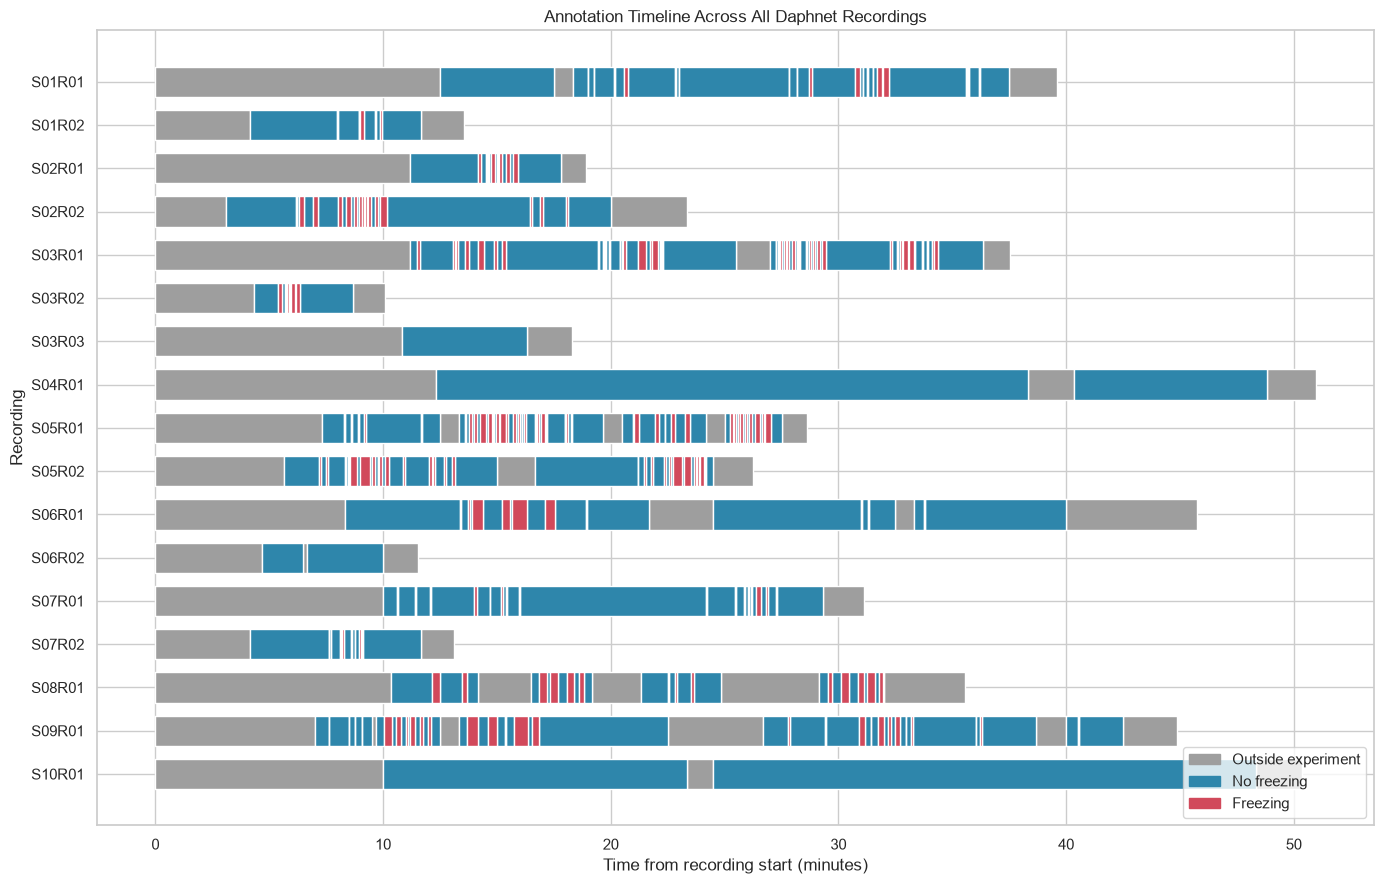

In [49]:
recording_names = (
    timeline_data["recording_name"]
    .drop_duplicates()
    .tolist()
)

fig, ax = plt.subplots(figsize=(14, 9))

for row_number, recording_name in enumerate(recording_names):
    recording_segments = timeline_data[
        timeline_data["recording_name"] == recording_name
    ]

    for label, color in LABEL_COLORS.items():
        label_segments = recording_segments[
            recording_segments["annotation"] == label
        ]

        intervals = list(
            zip(
                label_segments["start_minute"],
                label_segments["duration_minutes"],
            )
        )

        if intervals:
            ax.broken_barh(
                intervals,
                (row_number - 0.35, 0.7),
                facecolors=color,
            )

ax.set_yticks(range(len(recording_names)))
ax.set_yticklabels(recording_names)
ax.invert_yaxis()

ax.set_title("Annotation Timeline Across All Daphnet Recordings")
ax.set_xlabel("Time from recording start (minutes)")
ax.set_ylabel("Recording")

legend_items = [
    Patch(color=LABEL_COLORS[0], label="Outside experiment"),
    Patch(color=LABEL_COLORS[1], label="No freezing"),
    Patch(color=LABEL_COLORS[2], label="Freezing"),
]

ax.legend(
    handles=legend_items,
    loc="lower right",
)

plt.tight_layout()
plt.show()